In [1]:
import pandas as pd
from os import makedirs
from pathlib import Path

from hydra.core.analysis.utils import comparison_discovery

In [2]:
root_dir = "../../"

In [3]:
makedirs(f"{root_dir}figures/", exist_ok=True)

In [4]:
results = [results for path, results in comparison_discovery(f"{root_dir}samples")]
df = pd.DataFrame(results)

## Tables

In [5]:
from os import makedirs
from pathlib import Path

import pandas as pd

def build_ranked_df(df: pd.DataFrame, metrics: list[str]) -> pd.DataFrame:
    """
    Build the aggregated + ranked dataframe.

    Metric syntax:
      - "metric"                -> rank on metric, smaller is better
      - "-metric"               -> rank on the negated metric (useful when higher is better)
      - "[n]metric"             -> include metric in the output, but exclude it from avg_rank
      - dotted paths like
            "col.subkey.value"
        are resolved by reading df["col"] and then traversing nested dict keys.

    Ranking rule:
      - ranks are computed with ascending=True (1 = smallest/best)
      - if a metric is prefixed with '-', ranks are computed on the negative values
      - if a metric is prefixed with '[n]', it is not included in avg_rank
    """

    def _parse_metric_spec(metric: str) -> tuple[str, bool, bool]:
        """
        Return: (base_metric_name, invert_rank, exclude_from_avg_rank)

        Supports both prefix orders:
          -[n]metric
          [n]-metric
        """
        base = metric.strip()
        invert = False
        exclude_from_avg_rank = False

        changed = True
        while changed:
            changed = False
            if base.startswith("-"):
                invert = True
                base = base[1:]
                changed = True
            if base.startswith("[n]"):
                exclude_from_avg_rank = True
                base = base[3:]
                changed = True

        if not base:
            raise ValueError(f"Invalid metric specification: {metric!r}")

        return base, invert, exclude_from_avg_rank

    def _resolve_nested(value, keys: list[str]):
        current = value
        for key in keys:
            if isinstance(current, dict):
                if key not in current:
                    return pd.NA
                current = current[key]
            else:
                return pd.NA
        return current

    def _extract_metric_column(df: pd.DataFrame, metric_name: str) -> pd.Series:
        """
        Extract a metric series from the dataframe.

        Rules:
          - if metric_name is already a dataframe column, use it directly
          - otherwise, if metric_name is dotted (e.g. 'a.b.c'), use:
                df['a'].apply(lambda x: x['b']['c'])
            when possible
        """
        if metric_name in df.columns:
            return df[metric_name]

        parts = metric_name.split(".")
        root = parts[0]

        if root not in df.columns:
            raise KeyError(
                f"Missing metric '{metric_name}': "
                f"column '{root}' not found in df.columns"
            )

        if len(parts) == 1:
            return df[root]

        return df[root].apply(lambda v: _resolve_nested(v, parts[1:]))

    def _first(x):
        return x[0] if isinstance(x, (list, tuple)) else x

    metric_specs: list[tuple[str, bool, bool]] = []
    seen = set()
    for m in metrics:
        base, invert, exclude_from_avg_rank = _parse_metric_spec(m)
        if base not in seen:
            metric_specs.append((base, invert, exclude_from_avg_rank))
            seen.add(base)

    metric_cols = [base for base, _, _ in metric_specs]

    required_cols = ["name", "dataset_name", "kind"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise KeyError(f"Missing columns in df: {missing}")

    df_t = df[required_cols].copy()
    df_t["name"] = df_t["name"].apply(_first)
    df_t["kind"] = df_t["kind"].apply(_first)

    # Materialize metric columns, including dotted-path metrics.
    for base in metric_cols:
        df_t[base] = pd.to_numeric(_extract_metric_column(df, base), errors="coerce")

    df_agg = df_t.groupby(["dataset_name", "name", "kind"], as_index=False).mean(numeric_only=True)

    df_ranked = df_agg.copy()
    rank_cols = []
    for base, invert, exclude_from_avg_rank in metric_specs:
        if exclude_from_avg_rank:
            continue

        rank_col = f"{base}_rank"
        rank_input = -df_ranked[base] if invert else df_ranked[base]
        df_ranked[rank_col] = (
            rank_input.groupby([df_ranked["dataset_name"], df_ranked["kind"]])
            .rank(method="average", ascending=True)
        )
        rank_cols.append(rank_col)

    if rank_cols:
        df_ranked["avg_rank"] = df_ranked[rank_cols].mean(axis=1)
    else:
        df_ranked["avg_rank"] = float("nan")

    df_final = (
        df_ranked.drop(columns=rank_cols)
        .sort_values(["dataset_name", "kind", "avg_rank", "name"], na_position="last")
        .reset_index(drop=True)
    )
    return df_final

def _latex_escape(s: str) -> str:
    # minimal escaping for group labels used inside \multicolumn{...}{...}{...}
    return (str(s)
            .replace("\\", r"\textbackslash{}")
            .replace("&", r"\&")
            .replace("%", r"\%")
            .replace("$", r"\$")
            .replace("#", r"\#")
            .replace("_", r"\_")
            .replace("{", r"\{")
            .replace("}", r"\}")
            .replace("~", r"\textasciitilde{}")
            .replace("^", r"\textasciicircum{}"))

def make_grouped_latex_table(
    df_final: pd.DataFrame,
    out_path: str | Path,
    root_dir: str = "",
    font_cmd: str = r"\footnotesize",
) -> str:
    """
    Create the grouped LaTeX table (dataset_name header, then kind header) and save it.

    Returns the LaTeX string that was written to disk.
    """
    # Columns that will actually appear in the table (dataset/kind become group headers)
    data_cols = [c for c in df_final.columns if c not in ("dataset_name", "kind")]
    ncols = len(data_cols)

    # Build LaTeX manually, but reuse pandas to render the body rows safely
    col_format = "l" + "r" * (ncols - 1)  # first col left, the rest right

    lines: list[str] = []
    lines.append(r"\begingroup")
    lines.append(font_cmd)
    lines.append(r"\tiny")

    lines.append(r"\begin{tabular}{" + col_format + r"}")
    lines.append(r"\toprule")
    lines.append(" & ".join(_latex_escape(c) for c in data_cols) + r" \\")
    lines.append(r"\midrule")

    for dataset_name, ds_df in df_final.groupby("dataset_name", sort=False):
        lines.append(r"\midrule")
        lines.append(
            rf"\multicolumn{{{ncols}}}{{c}}{{\textbf{{{_latex_escape(dataset_name)}}}}} \\"
        )
        lines.append(r"\midrule")

        for kind, k_df in ds_df.groupby("kind", sort=False):
            lines.append(r"\midrule")
            lines.append(
                rf"\multicolumn{{{ncols}}}{{c}}{{\emph{{{_latex_escape(kind)}}}}} \\"
            )
            lines.append(r"\midrule")

            body = k_df[data_cols].to_latex(
                index=False,
                header=False,
                escape=True,
            ).splitlines()

            body = [
                ln for ln in body
                if not ln.startswith(r"\begin{tabular}")
                and not ln.startswith(r"\toprule")
                and not ln.startswith(r"\midrule")
                and not ln.startswith(r"\bottomrule")
                and not ln.startswith(r"\end{tabular}")
            ]
            lines.extend(body)

        lines.append(r"\midrule")

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\endgroup")

    latex_str = "\n".join(lines)

    out_path = Path(out_path)
    # Keep compatibility with your original pattern
    if root_dir:
        out_path = Path(root_dir) / out_path

    out_path.parent.mkdir(parents=True, exist_ok=True)
    out_path.write_text(latex_str, encoding="utf-8")
    return latex_str

In [6]:
metrics_kind = {
    "macroscopic.structure": [
        "incidence_matrix_density",
        "largest_connected_component_diameter",
        "clique_expansion_number_of_edges",
        "line_graph_number_of_edges"
    ],
    "macroscopic.size": [
        "number_of_nodes",
        "number_of_hyperedges",
    ],
    "macroscopic.community": [
        "clique_expansion_modularity",
        "hypergraph_modularity",
        "bipartite_graph_modularity",
        "line_graph_modularity"
    ],
    "mesoscopic.community": [
        "-normalized_mutual_information",
    ],
    "conditional_reconstruction": [
        "hyperedge_recovery.intersection",
        "hyperedge_recovery.jaccard_similarity"
    ]
}

for kind, metrics in metrics_kind.items():
    df_final = build_ranked_df(df, metrics)

    # (optional) keep this if you still use it elsewhere
    df_latex = (
        df_final
        .set_index(["dataset_name", "kind"])
        .sort_index()
    )

    # Save LaTeX table the same way (root_dir + tables/communities.tex)
    makedirs(f"{root_dir}tables/", exist_ok=True)
    make_grouped_latex_table(
        df_final=df_final,
        out_path=f"tables/{kind}.tex",
        root_dir=root_dir,
        font_cmd=r"\footnotesize",
    )

In [7]:
df_final = build_ranked_df(df, [
    "clique_expansion_modularity",
    "hypergraph_modularity",
    "bipartite_graph_modularity",
    "line_graph_modularity"
])

## Higher-order dissimilarity measures for hypergraph comparison

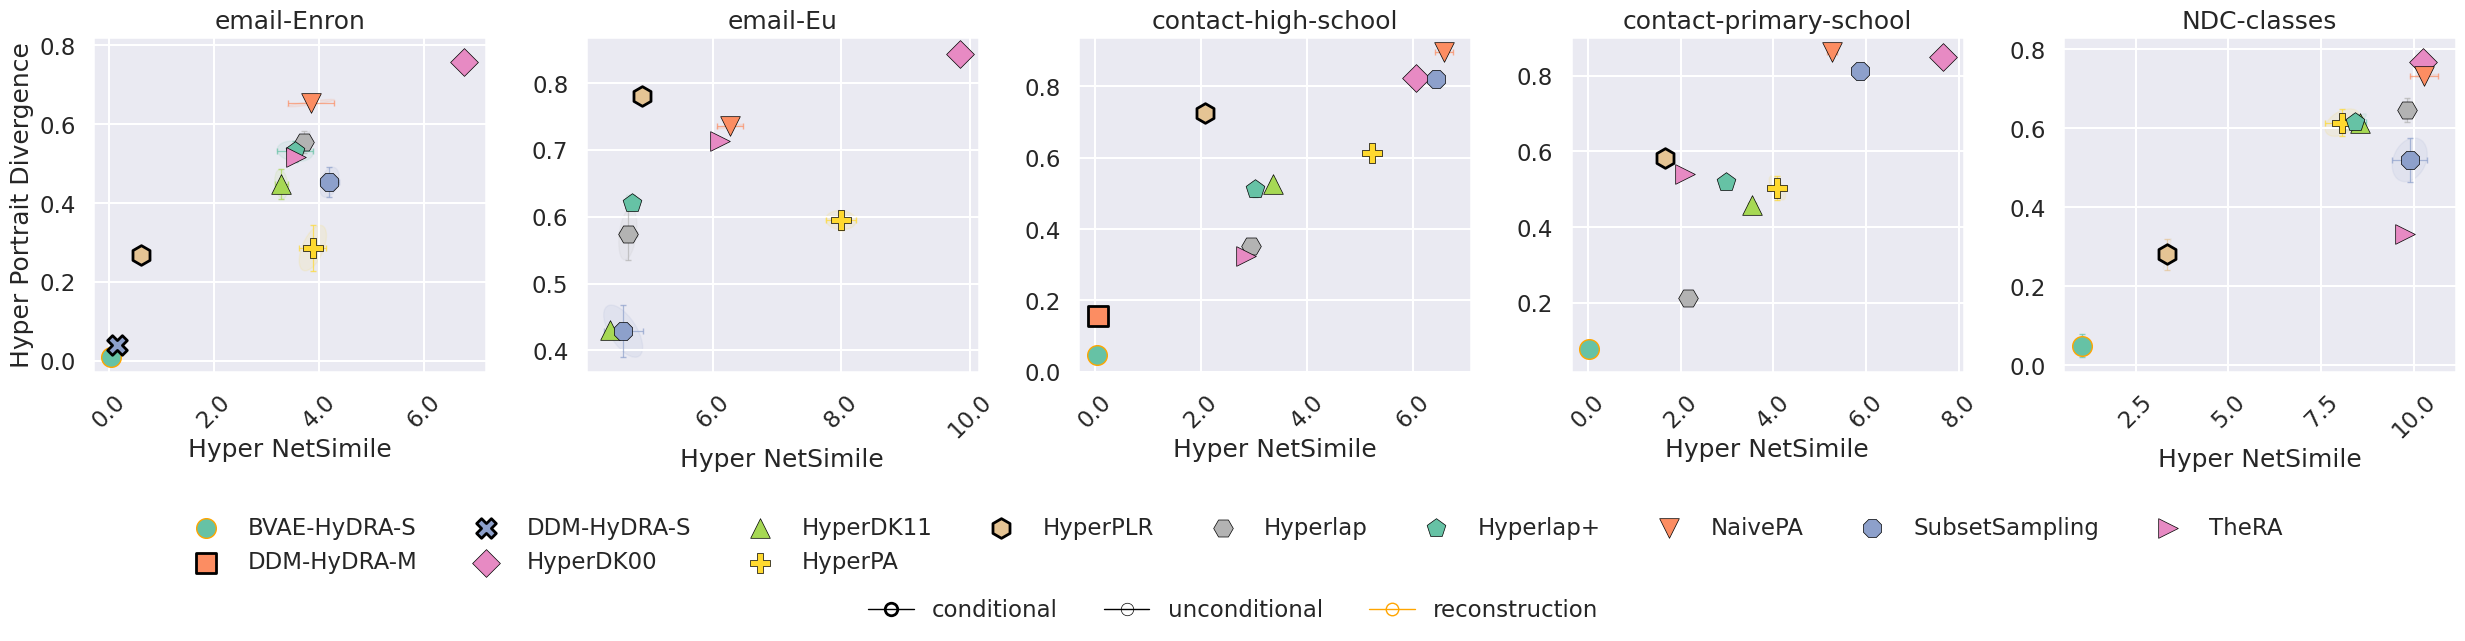

In [8]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse

df_dissimilarity = df.copy()

def _scalarize(x, *, lower=False):
    """If x is a 1-element container, unwrap it. If it's a string, keep it intact."""
    if isinstance(x, (list, tuple, np.ndarray)):
        if len(x) == 0:
            return np.nan
        x = x[0]
    if isinstance(x, str):
        x = x.strip()
        if lower:
            x = x.lower()
    return x

# Normalize ONCE (prevents "ModelA" vs "M" bugs)
df_dissimilarity["name"] = df_dissimilarity["name"].apply(_scalarize)
df_dissimilarity["kind"] = df_dissimilarity["kind"].apply(lambda v: _scalarize(v, lower=True))

def covariance_ellipse(
    ax, x, y, *, n_std=1.0, edgecolor="k", facecolor="none",
    alpha=0.12, lw=1.0, zorder=0
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if x.size < 3:
        return
    cov = np.cov(x, y)
    if not np.all(np.isfinite(cov)):
        return

    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]

    width, height = 2 * n_std * np.sqrt(np.maximum(vals, 0))
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))

    ell = Ellipse(
        (x.mean(), y.mean()),
        width, height,
        angle=angle,
        edgecolor=edgecolor,
        facecolor=facecolor,
        alpha=alpha,
        lw=lw,
        label="_nolegend_",
        zorder=zorder,
    )
    ax.add_patch(ell)

def _kind_proxy_handle(edgecolor, linewidth, linestyle):
    return Line2D(
        [0], [0],
        marker="o",
        linestyle=linestyle,
        color=edgecolor,
        markerfacecolor="none",
        markeredgecolor=edgecolor,
        markeredgewidth=linewidth,
        linewidth=1.0,
    )

KIND_EDGE_CONFIGS = [
    {"kinds": ["conditional"], "label": "conditional", "edgecolor": "black", "linewidth": 2.0, "linestyle": "solid"},
    {"kinds": ["unconditional"], "label": "unconditional", "edgecolor": "black", "linewidth": 0.5, "linestyle": "solid"},
    {"kinds": ["reconstruction"], "label": "reconstruction", "edgecolor": "orange", "linewidth": 1.0, "linestyle": "solid"},
]

def kind_edge_style(kind):
    kind = _scalarize(kind, lower=True)
    for cfg in KIND_EDGE_CONFIGS:
        kinds = cfg.get("kinds", [])
        if isinstance(kinds, str):
            kinds = [kinds]
        if kind in kinds:
            return {k: v for k, v in cfg.items() if k != "kinds"}
    raise ValueError(f"Kind '{kind}' not found in any KIND_EDGE_CONFIGS entry")

available_datasets = list(df_dissimilarity["dataset_name"].unique())
DATASET_ORDER = [
    "daqh/email-Enron",
    "daqh/email-Eu",
    "daqh/contact-high-school",
    "daqh/contact-primary-school",
    "daqh/NDC-classes"
]

def ordered_datasets(available, order=None, *, strict=True):
    if not order:
        return available
    missing = [d for d in order if d not in available]
    if missing and strict:
        raise ValueError(f"DATASET_ORDER contains unknown dataset_name(s): {missing}")
    ordered = [d for d in order if d in available]
    remainder = [d for d in available if d not in ordered]
    return ordered + remainder

unique_datasets = ordered_datasets(available_datasets, DATASET_ORDER, strict=True)

# consistent names across all subplots
all_names = sorted(df_dissimilarity["name"].dropna().unique())

# markers (one per name)
marker_list = ["o", "s", "X", "D", "^", "P", "h", "H", "p", "v", "8", ">", "*"]
marker_cycle = itertools.cycle(marker_list)
marker_map = {n: next(marker_cycle) for n in all_names}

# colors (one per name, fixed across all subplots)
palette = sns.color_palette("Set2", n_colors=len(all_names))
color_map = dict(zip(all_names, palette))

sns.set_theme(style="darkgrid", context="talk")

fig, ax = plt.subplots(ncols=len(unique_datasets), figsize=(5 * len(unique_datasets), 6))
if len(unique_datasets) == 1:
    ax = [ax]

# for the global legend (use actual plotted artists)
name_handles = {}

for i, dataset_name in enumerate(unique_datasets):
    df_raw = df_dissimilarity[df_dissimilarity["dataset_name"] == dataset_name][
        ["name", "kind", "hyper_net_simile", "hyper_portrait_divergence"]
    ].copy()

    df_stats = (
        df_raw.groupby("name", as_index=False)
        .agg(
            kind=("kind", lambda s: s.mode().iloc[0] if not s.mode().empty else s.iloc[0]),
            x_mean=("hyper_net_simile", "mean"),
            x_std=("hyper_net_simile", "std"),
            y_mean=("hyper_portrait_divergence", "mean"),
            y_std=("hyper_portrait_divergence", "std"),
        )
    )

    for _, r in df_stats.iterrows():
        n = r["name"]
        c = color_map[n]
        m = marker_map[n]
        es = kind_edge_style(r["kind"])

        sc = ax[i].scatter(
            r["x_mean"], r["y_mean"],
            s=200,
            marker=m,
            c=[c],
            edgecolors=es["edgecolor"],
            linewidths=es["linewidth"],
            linestyles=es["linestyle"],
            zorder=2,
            label="_nolegend_",
        )
        # store first-seen handle (not just i==0)
        if n not in name_handles:
            name_handles[n] = sc

        if np.isfinite(r["x_std"]) and np.isfinite(r["y_std"]):
            ax[i].errorbar(
                r["x_mean"], r["y_mean"],
                xerr=r["x_std"], yerr=r["y_std"],
                fmt="none",
                ecolor=c,
                elinewidth=0.9,
                capsize=2,
                alpha=0.7,
                zorder=1,
                label="_nolegend_",
            )

        sub = df_raw[df_raw["name"] == n]
        covariance_ellipse(
            ax[i],
            sub["hyper_net_simile"],
            sub["hyper_portrait_divergence"],
            n_std=1.0,
            edgecolor=c,
            facecolor=c,
            alpha=0.10,
            lw=1.0,
            zorder=0,
        )

    ax[i].set_title(dataset_name.split("/")[-1])
    ax[i].set_xlabel("Hyper NetSimile")
    ax[i].set_ylabel("Hyper Portrait Divergence" if i == 0 else "")
    ax[i].tick_params(axis="x", rotation=45)
    ax[i].xaxis.set_major_formatter(plt.FormatStrFormatter("%.1f"))
    ax[i].yaxis.set_major_formatter(plt.FormatStrFormatter("%.1f"))

handles = [name_handles[n] for n in all_names if n in name_handles]
labels = [n for n in all_names if n in name_handles]

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=max(1, int(len(labels) / 1.3)),
    frameon=False,
)

kind_handles = []
kind_labels = []
for cfg in KIND_EDGE_CONFIGS:
    kind_handles.append(_kind_proxy_handle(cfg["edgecolor"], cfg["linewidth"], cfg["linestyle"]))
    kind_labels.append(cfg.get("label", ",".join(cfg.get("kinds", []))))

fig.legend(
    kind_handles,
    kind_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=len(kind_labels),
    frameon=False,
)

fig.tight_layout()
fig.subplots_adjust(bottom=0.35)
makedirs(f"{root_dir}figures/", exist_ok=True)
fig.savefig(f"{root_dir}figures/dissimilarity_scatter.pdf", format="pdf", bbox_inches="tight")